In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout


from sklearn.linear_model import Perceptron

from tensorflow.keras.utils import to_categorical

In [7]:
df = pd.read_csv('mnist_train.csv')
df_test = pd.read_csv('mnist_test.csv')
df.head()

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.17,0.18,0.19,0.20,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30,0.31,0.32,0.33,0.34,0.35,0.36,0.37,0.38,...,0.578,0.579,0.580,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590,0.591,0.592,0.593,0.594,0.595,0.596,0.597,0.598,0.599,0.600,0.601,0.602,0.603,0.604,0.605,0.606,0.607,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,147,252,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
df.columns

Index(['5', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8',
       ...
       '0.608', '0.609', '0.610', '0.611', '0.612', '0.613', '0.614', '0.615',
       '0.616', '0.617'],
      dtype='object', length=785)

In [11]:
df.shape

(59999, 785)

In [13]:
df_test.head()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.17,0.18,0.19,0.20,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.30,0.31,0.32,0.33,0.34,0.35,0.36,0.37,0.38,...,0.628,0.629,0.630,0.631,0.632,0.633,0.634,0.635,0.636,0.637,0.638,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648,0.649,0.650,0.651,0.652,0.653,0.654,0.655,0.656,0.657,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
df.isnull().sum()

,0
5,0
0,0
0.1,0
0.2,0
0.3,0
...,...
0.613,0
0.614,0
0.615,0
0.616,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59999 entries, 0 to 59998
Columns: 785 entries, 5 to 0.617
dtypes: int64(785)
memory usage: 359.3 MB


In [14]:
#Preprocesses

X_train = df.drop('5', axis=1)
y_train = df['5']
X_test = df_test.drop('7', axis=1)
y_test = df_test['7']

In [21]:
X_train = X_train.astype('float32')/ 255.0
X_test = X_test.astype('float32')/ 255.0

In [23]:
X_train_img =  X_train.values.reshape(-1, 28, 28)
X_test_img =  X_test.values.reshape(-1, 28, 28)

In [26]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [27]:
# --- Perceptron ---

Perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation='softmax')
])

Perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics= ['accuracy'])

In [28]:
history_percep = Perceptron.fit(X_train_img, y_train_cat, epochs=5,batch_size = 32,
                                validation_data= (X_test_img, y_test_cat), verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8182 - loss: 0.7707 - val_accuracy: 0.8805 - val_loss: 0.4810
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8800 - loss: 0.4570 - val_accuracy: 0.8941 - val_loss: 0.4006
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8908 - loss: 0.4038 - val_accuracy: 0.9014 - val_loss: 0.3670
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8962 - loss: 0.3770 - val_accuracy: 0.9057 - val_loss: 0.3480
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9006 - loss: 0.3600 - val_accuracy: 0.9086 - val_loss: 0.3363


In [29]:
# --- Accuracy of a Perceptron Model ---
acc_percep = Perceptron.evaluate(X_test_img, y_test_cat)[1]
acc_percep

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9086 - loss: 0.3363


0.9085908532142639

In [30]:
# --- ANN ---
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics= ['accuracy'])

In [34]:
history_ann = ann.fit(X_train_img, y_train_cat, batch_size=32, epochs= 5,
                      validation_data= (X_test_img, y_test_cat), verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9295 - loss: 0.2431 - val_accuracy: 0.9605 - val_loss: 0.1264
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9686 - loss: 0.1035 - val_accuracy: 0.9633 - val_loss: 0.1166
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9774 - loss: 0.0725 - val_accuracy: 0.9730 - val_loss: 0.0860
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0567 - val_accuracy: 0.9737 - val_loss: 0.0865
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9847 - loss: 0.0457 - val_accuracy: 0.9771 - val_loss: 0.0743


In [35]:
# --- Accuracy of an ANN model ---
acc_ann = ann.evaluate(X_test_img, y_test_cat)[1]
acc_ann

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9771 - loss: 0.0743


0.9770976901054382

In [36]:
X_train_cnn =  X_train.values.reshape(-1, 28, 28, 1)  # The last num is num of layers 1 for black and white.
X_test_cnn =  X_test.values.reshape(-1, 28, 28, 1)

In [40]:
# --- CNN ---

cnn = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),   # convert to a iD array
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics= ['accuracy'])

In [41]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32,
                      validation_data= (X_test_cnn, y_test_cat), verbose = 1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9297 - loss: 0.2317 - val_accuracy: 0.9801 - val_loss: 0.0605
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9746 - loss: 0.0880 - val_accuracy: 0.9897 - val_loss: 0.0331
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9819 - loss: 0.0615 - val_accuracy: 0.9900 - val_loss: 0.0313
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9859 - loss: 0.0487 - val_accuracy: 0.9916 - val_loss: 0.0264
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9873 - loss: 0.0412 - val_accuracy: 0.9910 - val_loss: 0.0268


In [42]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat)[1]
acc_cnn

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9910 - loss: 0.0268


0.9909991025924683

### Model Performance Comparison: Accuracy and Loss

Let's compare the training and validation accuracy and loss curves for the Perceptron, ANN, and CNN models.

### Performance Comparison of Perceptron, ANN, and CNN Models

Let's summarize and compare the final validation accuracy and loss for each model.

,Model,Validation Accuracy,Validation Loss
0,Perceptron,0.908591,0.336315
1,ANN,0.977098,0.074322
2,CNN,0.990999,0.026774


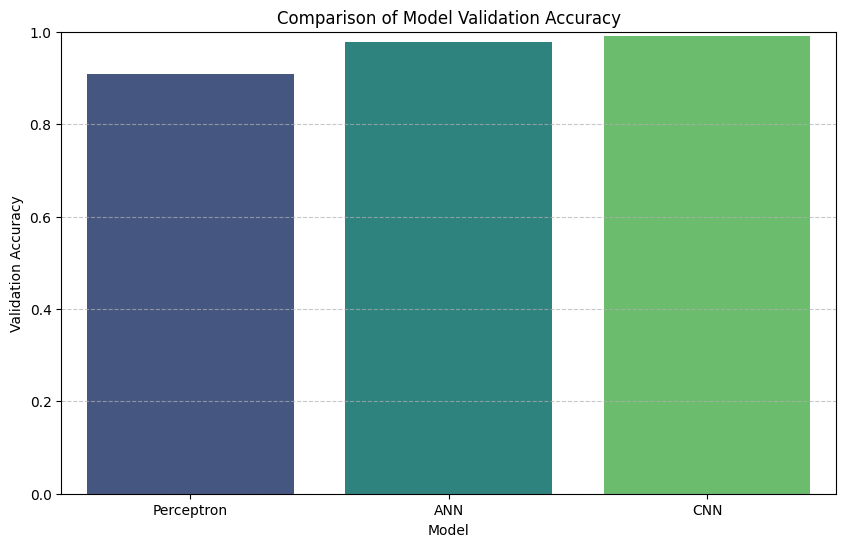

In [47]:
model_names = ['Perceptron', 'ANN', 'CNN']
accuracies = [acc_percep, acc_ann, acc_cnn]
losses = [history_percep.history['val_loss'][-1], history_ann.history['val_loss'][-1], history_cnn.history['val_loss'][-1]]

performance_df = pd.DataFrame({
    'Model': model_names,
    'Validation Accuracy': accuracies,
    'Validation Loss': losses
})

display(performance_df)

# Visualize accuracy comparison with a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Validation Accuracy', data=performance_df, palette='viridis')
plt.title('Comparison of Model Validation Accuracy')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Validation Accuracy Increase Comparison of All Three Models

This graph shows how the validation accuracy of each model improved over the training epochs, allowing for a direct comparison of their learning performance.

### Validation Loss Decrease Comparison of All Three Models

This graph illustrates how the validation loss of each model changed over the training epochs, providing insight into their learning efficiency and convergence.

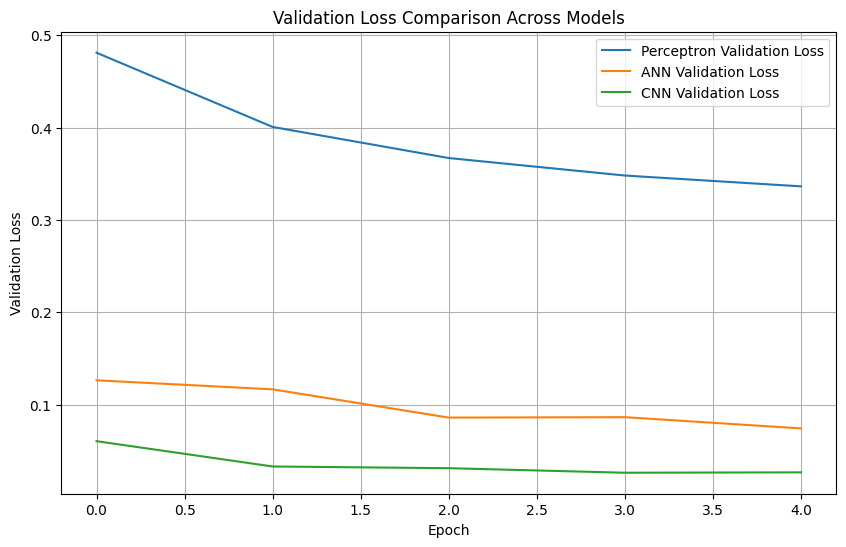

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(history_percep.history['val_loss'], label='Perceptron Validation Loss')
plt.plot(history_ann.history['val_loss'], label='ANN Validation Loss')
plt.plot(history_cnn.history['val_loss'], label='CNN Validation Loss')

plt.title('Validation Loss Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

### Visualizing Model Predictions

Let's pick 5 random images from the test set and see how each of our trained models (Perceptron, ANN, and CNN) predict their digits. We will compare their predictions against the true labels.

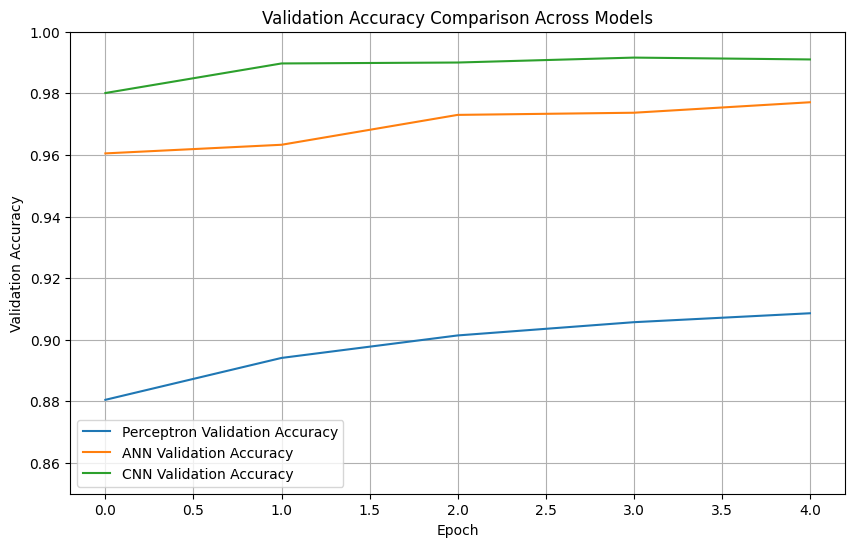

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(history_percep.history['val_accuracy'], label='Perceptron Validation Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation Accuracy')

plt.title('Validation Accuracy Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0.85, 1.0) # Focus on the relevant accuracy range for better visualization
plt.show()

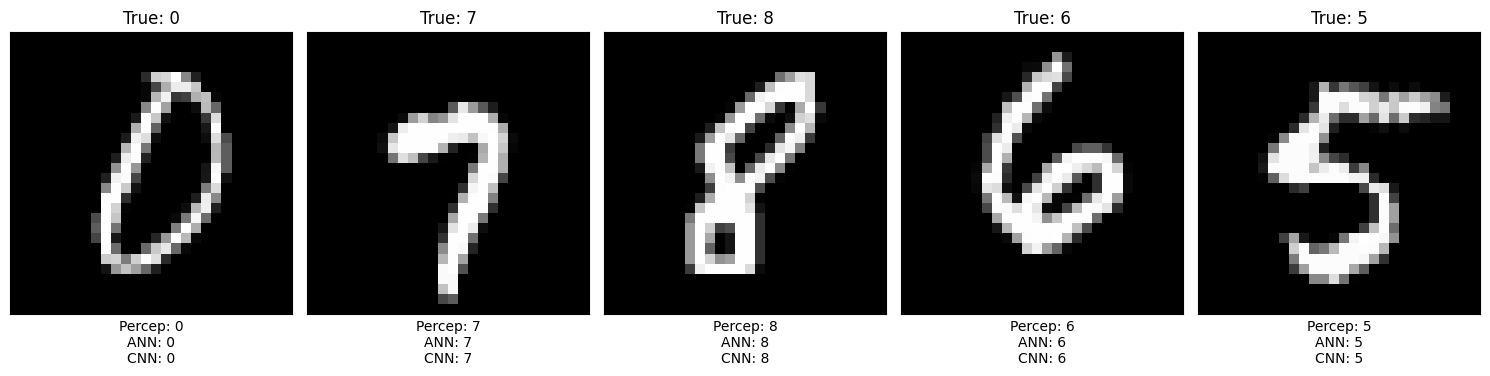

In [54]:
num_samples = 5

# Select 5 random indices from the test set
random_indices = np.random.randint(0, len(X_test_img), num_samples)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(random_indices):
    # Original image for display
    img = X_test_img[idx]

    # Prepare image for each model (reshaping if necessary)
    # Perceptron and ANN use X_test_img (28, 28)
    # CNN uses X_test_cnn (28, 28, 1)

    # Get true label
    true_label = np.argmax(y_test_cat[idx])

    # Get predictions
    percep_pred_proba = Perceptron.predict(np.expand_dims(X_test_img[idx], axis=0), verbose=0)[0]
    ann_pred_proba = ann.predict(np.expand_dims(X_test_img[idx], axis=0), verbose=0)[0]
    cnn_pred_proba = cnn.predict(np.expand_dims(X_test_cnn[idx], axis=0), verbose=0)[0]

    percep_pred = np.argmax(percep_pred_proba)
    ann_pred = np.argmax(ann_pred_proba)
    cnn_pred = np.argmax(cnn_pred_proba)

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label}")
    plt.xlabel(f"Percep: {percep_pred}\nANN: {ann_pred}\nCNN: {cnn_pred}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()